# PS0 – Smoking-Attributable Healthcare Expenditures

## 1. Research Question and Motivation

**Research Question:**  
How do smoking-attributable healthcare expenditures vary across U.S. states,
healthcare service categories, and time?

Cigarette smoking creates substantial public-health and economic consequences.
This project uses the CDC Smoking-Attributable Mortality, Morbidity, and
Economic Costs (SAMMEC) – Smoking-Attributable Expenditures (SAE) dataset
to examine the healthcare costs attributable to smoking.

The goal of this initial analysis is to determine which healthcare service
categories account for the largest smoking-attributable expenditures, how
these costs vary across states, and how average state-level expenditures
changed from 2005 through 2009.

This dataset is useful because it provides quantitative estimates of the
economic burden associated with smoking across multiple U.S. locations,
years, and healthcare expenditure categories.

### Hypothesis

Hospital care will account for the largest average smoking-attributable
healthcare expenditure among the healthcare service categories, and average
state-level smoking-attributable healthcare expenditures will increase from
2005 to 2009.

## 2. Potential Datasets for the Final Project

### Dataset 1 – Smoking-Attributable Expenditures
The CDC SAMMEC Smoking-Attributable Expenditures dataset is used in this
PS0 analysis. It measures healthcare expenditures attributable to cigarette
smoking across U.S. locations and healthcare service categories.

### Dataset 2 – Obesity and Physical Health

The second dataset selected for this project is the CDC Nutrition,
Physical Activity, and Obesity – Behavioral Risk Factor Surveillance System
dataset.

The dataset contains 110,880 observations and 33 variables covering
2011–2024 across 55 geographic locations. It includes measures related to
obesity and weight status, physical activity, and nutrition.

It also contains demographic information by age, education, sex, income,
and race/ethnicity.

This dataset provides detailed state-level information that may later be
used to investigate relationships among obesity, health behaviors, and
health-related economic burden.

### Dataset 3 – Mental and Emotional Health

The third dataset selected for this project is the CDC Behavioral Risk
Factor Surveillance System (BRFSS) Prevalence Data.

This is a large state-level dataset containing a wide range of health
indicators collected through BRFSS. For this project, the dataset will be
filtered to focus specifically on mental and emotional health measures,
such as poor mental health or mental distress indicators.

The dataset is useful because it provides state-level observations across
multiple years and can potentially be compared with the obesity dataset
using common variables such as geographic location and year.

Only the mental-health-related variables needed for the analysis will be
retained in later stages of the project.

## 3. Data Sources

### Dataset 1 – Smoking-Attributable Expenditures

**Dataset:** Smoking-Attributable Mortality, Morbidity, and Economic Costs
(SAMMEC) – Smoking-Attributable Expenditures (SAE)

**Source:** Centers for Disease Control and Prevention (CDC)

**Years:** 2005–2009

**Unit:** Millions of dollars

**Exact source URL:**  
https://data.cdc.gov/Health-Consequences-and-Costs/Smoking-Attributable-Mortality-Morbidity-and-Econo/ezab-8sq5/data_preview


### Dataset 2 – Obesity and Physical Health

**Dataset:** Nutrition, Physical Activity, and Obesity – Behavioral Risk Factor Surveillance System

**Source:** Centers for Disease Control and Prevention (CDC)

**Years:** 2011–2024

**Observations:** 110,880

**Variables:** 33

**Geographic Coverage:** 55 locations

**Exact source URL:**  
https://data.cdc.gov/Nutrition-Physical-Activity-and-Obesity/Nutrition-Physical-Activity-and-Obesity-Behavioral/hn4x-zwk7/data_preview


### Dataset 3 – Mental and Emotional Health

**Dataset:** Behavioral Risk Factor Surveillance System (BRFSS) Prevalence Data

**Source:** Centers for Disease Control and Prevention (CDC)

**Years:** 2011–Present

**Geographic Coverage:** U.S. states and participating jurisdictions

**Main Use in Project:** Mental and emotional health indicators

**Potential Measures:** Poor mental health, mental distress, depression-related
indicators, and other behavioral-health measures available in BRFSS.

**Exact source URL:**  
https://data.cdc.gov/Behavioral-Risk-Factors/Behavioral-Risk-Factor-Surveillance-System-BRFSS-P/dttw-5yxu/data

## 4. Setup

In [93]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## 5. Load the Data

In [94]:
dat = pd.read_csv(
    "https://data.cdc.gov/api/views/ezab-8sq5/rows.csv?accessType=DOWNLOAD"
)

## 6. Initial Data Exploration


In [95]:
dat.head()

,Year,LocationAbbr,LocationDesc,DataSource,TopicType,TopicDesc,MeasureDesc,Variable,Data_Value_Unit,Data_Value_Type,Data_Value,Data_Value_Footnote_Symbol,Data_Value_Footnote,GeoLocation,Topic Type ID,Topic ID,Measure ID,SubMeasureID,DisplayOrder
0,2009,RI,Rhode Island,SAMMEC,Health Consequences and Costs,Smoking-Attributable Expenditures (SAEs),Type of Expense,Other,$,Millions of Dollars,47.2,*,"Other expenditures include home health care, d...","RI\n(41.708280193, -71.522470314)",HLT,501HLT,520SAE,SAE006,6
1,2007,SD,South Dakota,SAMMEC,Health Consequences and Costs,Smoking-Attributable Expenditures (SAEs),Type of Expense,Nursing Home,$,Millions of Dollars,29.2,NaN,NaN,"SD\n(44.353130053, -100.373530637)",HLT,501HLT,520SAE,SAE005,5
2,2009,NH,New Hampshire,SAMMEC,Health Consequences and Costs,Smoking-Attributable Expenditures (SAEs),Type of Expense,Other,$,Millions of Dollars,41.4,*,"Other expenditures include home health care, d...","NH\n(43.655950113, -71.50036092)",HLT,501HLT,520SAE,SAE006,6
3,2006,MD,Maryland,SAMMEC,Health Consequences and Costs,Smoking-Attributable Expenditures (SAEs),Type of Expense,Prescription Drugs,$,Millions of Dollars,465.2,NaN,NaN,"MD\n(39.290580964, -76.609260111)",HLT,501HLT,520SAE,SAE004,4
4,2009,LA,Louisiana,SAMMEC,Health Consequences and Costs,Smoking-Attributable Expenditures (SAEs),Type of Expense,Other,$,Millions of Dollars,117.5,*,"Other expenditures include home health care, d...","LA\n(31.312660644, -92.445680071)",HLT,501HLT,520SAE,SAE006,6


In [96]:
dat.tail()

,Year,LocationAbbr,LocationDesc,DataSource,TopicType,TopicDesc,MeasureDesc,Variable,Data_Value_Unit,Data_Value_Type,Data_Value,Data_Value_Footnote_Symbol,Data_Value_Footnote,GeoLocation,Topic Type ID,Topic ID,Measure ID,SubMeasureID,DisplayOrder
1555,2008,US,United States,SAMMEC,Health Consequences and Costs,Smoking-Attributable Expenditures (SAEs),Type of Expense,Ambulatory,$,Millions of Dollars,20233.0,NaN,NaN,"US\n(38.883, 77.017)",HLT,501HLT,520SAE,SAE002,2
1556,2005,US,United States,SAMMEC,Health Consequences and Costs,Smoking-Attributable Expenditures (SAEs),Type of Expense,Hospital,$,Millions of Dollars,53556.1,NaN,NaN,"US\n(38.883, 77.017)",HLT,501HLT,520SAE,SAE003,3
1557,2008,US,United States,SAMMEC,Health Consequences and Costs,Smoking-Attributable Expenditures (SAEs),Type of Expense,Other,$,Millions of Dollars,7690.3,*,"Other expenditures include home health care, d...","US\n(38.883, 77.017)",HLT,501HLT,520SAE,SAE006,6
1558,2008,US,United States,SAMMEC,Health Consequences and Costs,Smoking-Attributable Expenditures (SAEs),Type of Expense,Prescription Drugs,$,Millions of Dollars,24351.3,NaN,NaN,"US\n(38.883, 77.017)",HLT,501HLT,520SAE,SAE004,4
1559,2009,US,United States,SAMMEC,Health Consequences and Costs,Smoking-Attributable Expenditures (SAEs),Type of Expense,Nursing Home,$,Millions of Dollars,10646.8,NaN,NaN,"US\n(38.883, 77.017)",HLT,501HLT,520SAE,SAE005,5


In [97]:
dat.shape

(1560, 19)

In [98]:
dat.columns

Index(['Year', 'LocationAbbr', 'LocationDesc', 'DataSource', 'TopicType',
       'TopicDesc', 'MeasureDesc', 'Variable', 'Data_Value_Unit',
       'Data_Value_Type', 'Data_Value', 'Data_Value_Footnote_Symbol',
       'Data_Value_Footnote', 'GeoLocation', 'Topic Type ID', 'Topic ID',
       'Measure ID', 'SubMeasureID', 'DisplayOrder'],
      dtype='object')

In [99]:
dat.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1560 entries, 0 to 1559
Data columns (total 19 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Year                        1560 non-null   int64  
 1   LocationAbbr                1560 non-null   object 
 2   LocationDesc                1560 non-null   object 
 3   DataSource                  1560 non-null   object 
 4   TopicType                   1560 non-null   object 
 5   TopicDesc                   1560 non-null   object 
 6   MeasureDesc                 1560 non-null   object 
 7   Variable                    1560 non-null   object 
 8   Data_Value_Unit             1560 non-null   object 
 9   Data_Value_Type             1560 non-null   object 
 10  Data_Value                  1560 non-null   float64
 11  Data_Value_Footnote_Symbol  520 non-null    object 
 12  Data_Value_Footnote         520 non-null    object 
 13  GeoLocation                 1560 

In [100]:
dat.isnull().sum()

,0
Year,0
LocationAbbr,0
LocationDesc,0
DataSource,0
TopicType,0
TopicDesc,0
MeasureDesc,0
Variable,0
Data_Value_Unit,0
Data_Value_Type,0


In [101]:
dat["Variable"].value_counts()

,count
Variable,
Other,260
Nursing Home,260
Prescription Drugs,260
Ambulatory,260
Hospital,260
Total,260


In [102]:
dat["Year"].value_counts().sort_index()

,count
Year,
2005,312
2006,312
2007,312
2008,312
2009,312


In [103]:
dat[["Data_Value", "Data_Value_Type", "Data_Value_Unit"]].head(10)

,Data_Value,Data_Value_Type,Data_Value_Unit
0,47.2,Millions of Dollars,$
1,29.2,Millions of Dollars,$
2,41.4,Millions of Dollars,$
3,465.2,Millions of Dollars,$
4,117.5,Millions of Dollars,$
5,555.8,Millions of Dollars,$
6,376.0,Millions of Dollars,$
7,319.0,Millions of Dollars,$
8,503.5,Millions of Dollars,$
9,4369.6,Millions of Dollars,$


In [104]:
dat["Data_Value_Type"].value_counts()

,count
Data_Value_Type,
Millions of Dollars,1560


In [105]:
dat["Data_Value"].head(10)

,Data_Value
0,47.2
1,29.2
2,41.4
3,465.2
4,117.5
5,555.8
6,376.0
7,319.0
8,503.5
9,4369.6


In [106]:
dat["LocationDesc"].nunique()

52

In [107]:
dat["LocationDesc"].unique()

array(['Rhode Island', 'South Dakota', 'New Hampshire', 'Maryland',
       'Louisiana', 'Tennessee', 'Wisconsin', 'Missouri', 'Texas',
       'Nevada', 'New Mexico', 'Utah', 'North Dakota', 'Arkansas',
       'Pennsylvania', 'California', 'Michigan', 'Colorado',
       'Connecticut', 'North Carolina', 'Hawaii', 'Delaware',
       'South Carolina', 'Kansas', 'Oklahoma', 'Arizona', 'Iowa', 'Idaho',
       'Virginia', 'New Jersey', 'Ohio', 'Indiana', 'Alabama',
       'Mississippi', 'Florida', 'Illinois', 'Wyoming',
       'District of Columbia', 'New York', 'Maine', 'Alaska', 'Georgia',
       'Kentucky', 'Minnesota', 'Vermont', 'Washington', 'Massachusetts',
       'West Virginia', 'Nebraska', 'Montana', 'Oregon', 'United States'],
      dtype=object)

### Initial Data Interpretation

The dataset contains **1,560 observations** covering five years
(2005–2009), 52 geographic locations, and six expenditure categories.
The locations consist of the U.S. states, the District of Columbia, and
a national United States observation.

Each year contains the same number of observations, and each healthcare
expense category appears consistently throughout the dataset. Missing values
occur primarily in the footnote-related fields, while the main analytical
variables contain complete observations.

## 7. Data Cleaning

In [108]:
dat["Data_Value_Num"] = pd.to_numeric(
    dat["Data_Value"],
    errors="coerce"
)

In [109]:
dat["Data_Value_Num"].isnull().sum()

np.int64(0)

In [110]:
dat[["Data_Value", "Data_Value_Num"]].head(10)

,Data_Value,Data_Value_Num
0,47.2,47.2
1,29.2,29.2
2,41.4,41.4
3,465.2,465.2
4,117.5,117.5
5,555.8,555.8
6,376.0,376.0
7,319.0,319.0
8,503.5,503.5
9,4369.6,4369.6


In [111]:
dat["Data_Value_Num"].dtype

dtype('float64')

### Data Cleaning Interpretation

The `Data_Value` field from the online CDC dataset was converted explicitly
to numeric format using `pd.to_numeric()`.

A separate numeric variable, `Data_Value_Num`, was created to ensure that
the expenditure values could be used consistently for descriptive statistics,
group comparisons, and visualizations.

The conversion produced numeric floating-point values suitable for the
subsequent analysis.

## 8. Descriptive Statistics

In [112]:
dat["Data_Value_Num"].describe()

,Data_Value_Num
count,1560.000000
mean,1545.223462
std,7868.553085
min,8.400000
25%,105.675000
50%,306.150000
75%,842.300000
max,132459.800000


In [113]:
dat["Data_Value_Num"].mean()

np.float64(1545.2234615384616)

In [114]:
dat["Data_Value_Num"].median()

306.15

In [115]:
dat["Data_Value_Num"].std()

7868.553084944178

In [116]:
dat["Data_Value_Num"].min()

8.4

In [117]:
dat["Data_Value_Num"].max()

132459.8

### Interpretation

The dataset contains 1,560 observations of smoking-attributable healthcare
expenditures. The average expenditure is approximately **$1,545.2 million**,
while the median is only **$306.2 million**.

The substantial difference between the mean and median indicates a strongly
right-skewed distribution. A relatively small number of very large expenditure
values increase the overall mean. Expenditures range from **$8.4 million**
to **$132,459.8 million**, demonstrating substantial variation across
locations, years, and healthcare expense categories.

## 9. Healthcare Expenditure Categories

In [118]:
dat_total = dat[dat["Variable"] == "Total"]

dat_total.shape

(260, 20)

In [119]:
dat_total["Data_Value_Num"].describe()

,Data_Value_Num
count,260.000000
mean,4635.667308
std,16431.255205
min,193.900000
25%,657.600000
50%,1683.350000
75%,2955.700000
max,132459.800000


In [120]:
dat_categories = dat[
    (dat["Variable"] != "Total") &
    (dat["LocationDesc"] != "United States")
]

dat_categories.shape

(1275, 20)

In [121]:
dat_categories.groupby("Variable")[
    "Data_Value_Num"
].mean().sort_values(ascending=False)

,Data_Value_Num
Variable,
Hospital,1224.714902
Prescription Drugs,452.441569
Ambulatory,364.320392
Nursing Home,187.146275
Other,143.309804


### Expenditure by Healthcare Category

Hospital care had the highest average smoking-attributable healthcare expenditure
at approximately **1,224.7 million dollars**.

Prescription drug expenditures were the second highest at approximately
**452.4 million dollars**, followed by ambulatory care at approximately
**364.3 million dollars**. Nursing home expenditures averaged approximately
**187.1 million dollars**, while other expenditures averaged approximately
**143.3 million dollars**.

This shows that hospital care represents the largest average healthcare expenditure
category associated with smoking among the state-level locations in this dataset.

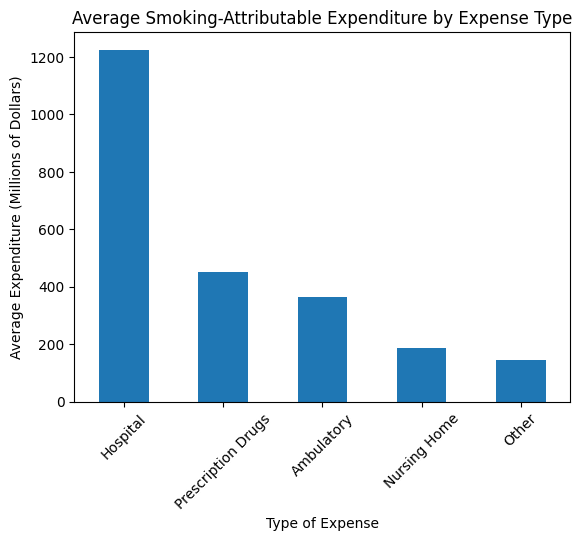

In [122]:
dat_categories.groupby("Variable")[
    "Data_Value_Num"
].mean().sort_values(ascending=False).plot(kind="bar")

plt.xlabel("Type of Expense")
plt.ylabel("Average Expenditure (Millions of Dollars)")
plt.title("Average Smoking-Attributable Expenditure by Expense Type")
plt.xticks(rotation=45)
plt.show()

## 10. Changes in Expenditure Over Time

In [123]:
dat_states = dat_total[
    dat_total["LocationDesc"] != "United States"
]

In [124]:
dat_states.groupby("Year")[
    "Data_Value_Num"
].mean()

,Data_Value_Num
Year,
2005,2112.354902
2006,2252.115686
2007,2382.894118
2008,2495.815686
2009,2616.456863


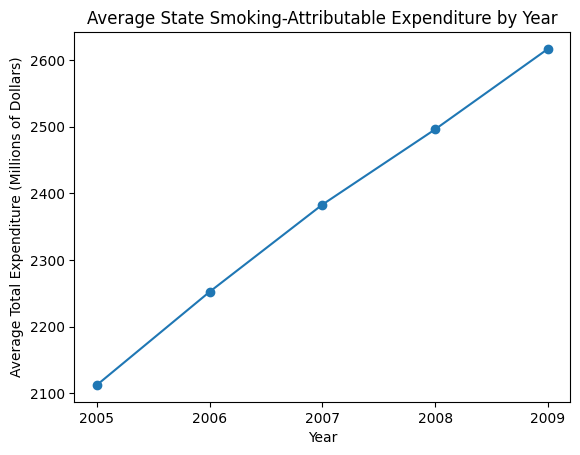

In [125]:
years = dat_states.groupby("Year")["Data_Value_Num"].mean()

years.plot(kind="line", marker="o")

plt.xlabel("Year")
plt.ylabel("Average Total Expenditure (Millions of Dollars)")
plt.title("Average State Smoking-Attributable Expenditure by Year")
plt.xticks(years.index)
plt.show()

The average state-level smoking-attributable healthcare expenditure increased
consistently from approximately $2,112.4 million in 2005 to $2,616.5 million
in 2009.

This represents an increase of about $504 million in average state expenditure
over the five-year period.

The data show a steady increase in reported average state-level
smoking-attributable healthcare expenditures during the period covered by
the dataset.

In [126]:
dat_states.nlargest(
    10,
    "Data_Value_Num"
)[["Year", "LocationDesc", "Data_Value_Num"]]

,Year,LocationDesc,Data_Value_Num
1267,2009,California,13292.4
457,2008,California,12659.3
1225,2007,California,11896.6
84,2006,California,11170.8
523,2005,California,10460.5
1123,2009,New York,10389.8
789,2008,New York,9904.0
1500,2007,New York,9639.2
334,2006,New York,9237.4
100,2009,Texas,8855.6


## 11. State-Level Comparison

In [127]:
state_avg = (
    dat_states.groupby("LocationDesc")["Data_Value_Num"]
    .mean()
    .sort_values(ascending=False)
)

state_avg.head(10)

,Data_Value_Num
LocationDesc,
California,11895.92
New York,9584.58
Texas,7874.26
Florida,7768.70
Pennsylvania,5884.60
Ohio,5206.16
Illinois,5015.84
Michigan,4222.92
New Jersey,3785.90


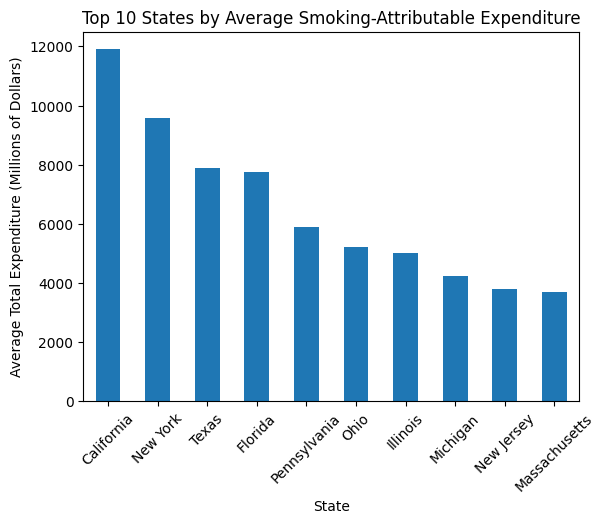

In [128]:
state_avg.head(10).plot(kind="bar")

plt.xlabel("State")
plt.ylabel("Average Total Expenditure (Millions of Dollars)")
plt.title("Top 10 States by Average Smoking-Attributable Expenditure")
plt.xticks(rotation=45)
plt.show()

### Interpretation

California had the highest average smoking-attributable healthcare
expenditure during 2005–2009 at approximately **$11,895.9 million**.
New York ranked second at approximately **$9,584.6 million**, followed
by Texas and Florida.

The results show substantial differences in total smoking-attributable
healthcare expenditures among states. However, larger states also have
larger populations, so total expenditures should not automatically be
interpreted as indicating a higher individual smoking burden.

A future analysis could calculate expenditure per capita to improve
comparability across states.

## 12. Conclusion

This PS0 analysis examined smoking-attributable healthcare expenditures
using the CDC SAMMEC dataset for 2005–2009.

The results show substantial differences in smoking-attributable healthcare
costs across healthcare categories, geographic locations, and years.
Hospital care represented the largest average expenditure category, and
average state-level smoking-attributable expenditures increased steadily
over the five-year period.

California, New York, Texas, and Florida had the highest average total
expenditures. The overall expenditure distribution was strongly right-skewed,
showing that a relatively small number of very large observations substantially
influenced the overall average.

This dataset provides a useful starting point for a broader health-related
project. A second CDC dataset related to obesity, physical activity, and
nutrition has been selected, along with a third CDC BRFSS dataset containing
mental and emotional health indicators.

Future problem sets will examine how these datasets can be analyzed together
or compared at a common geographic level such as U.S. states. Particular
attention will be given to differences in time coverage and to identifying
common variables, such as geographic location and year, that may support
future comparisons or data integration.

## Code and Assistance Note

The pandas syntax and general coding approach used in this notebook are
based in part on examples demonstrated in the course pandas notebook.

ChatGPT was used to assist with adapting pandas code to the CDC SAMMEC
dataset, organizing the analysis, cleaning the expenditure variable,
developing descriptive analyses and visualizations, and reviewing the
interpretation of results.